In [16]:
import os
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import yaml
import random
import shutil
from sklearn.model_selection import train_test_split
import ultralytics
from ultralytics import YOLO

Primeira imagem: /home/pvbm.eng23/dataset_topicos/images_train/100018.png


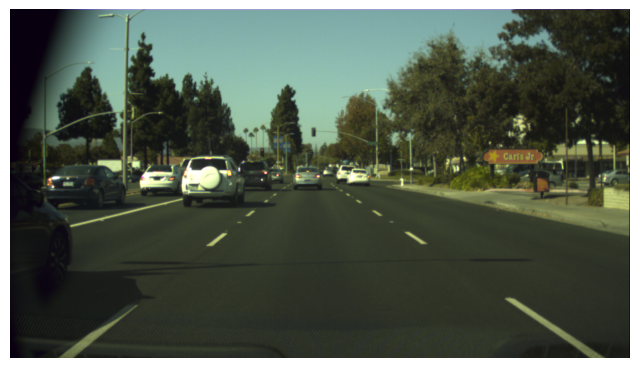

In [50]:
path = Path("/home/pvbm.eng23/dataset_topicos/images_train")

print(f"Primeira imagem: {imagens[0]}")

img = Image.open(imagens[0])

plt.figure(figsize=(8, 6))
plt.imshow(img)
plt.axis("off")
plt.show()

In [2]:
import torch

a = torch.rand(1000, 4, device="cuda")
b = torch.rand(1000, 4, device="cuda")

for _ in range(1000):
    c = torch.min(a.unsqueeze(1), b.unsqueeze(0))

In [64]:
random.seed(42)

images_path = dataset_path / "images_train"

imgs= list(Path(images_path).glob("*.png"))

saida = dataset_path / "dataset_yolo"

treino = 1000
validacao = 150
teste = 300

random.seed(42)

imgs = random.sample(imgs, 1450)

train_imgs, temp_imgs = train_test_split(
    imgs,
    train_size=1000,
    random_state=42
)

val_imgs, test_imgs = train_test_split(
    temp_imgs,
    train_size=150,
    random_state=42
)

print(len(train_imgs))
print(len(val_imgs))
print(len(test_imgs))

1000
150
300


In [62]:
for pasta in ["train", "val", "test"]:
    (dataset_path / "images" / pasta).mkdir(
        parents=True,
        exist_ok=True
    )

    (dataset_path / "labels" / pasta).mkdir(
        parents=True,
        exist_ok=True
    )

In [65]:
for img in train_imgs:
    shutil.copy2(
        img,
        dataset_path / "images/train" / img.name
    )

for img in val_imgs:
    shutil.copy2(
        img,
        dataset_path / "images/val" / img.name
    )

for img in test_imgs:
    shutil.copy2(
        img,
        dataset_path / "images/test" / img.name
    )

In [56]:
train_names = {img.name for img in train_imgs}
val_names = {img.name for img in val_imgs}
test_names = {img.name for img in test_imgs}

In [57]:
CLASS_MAP = {
    "Red": 0,
    "RedLeft": 0,
    "RedRight": 0,

    "Yellow": 1,
    "YellowLeft": 1,
    "YellowRight": 1,

    "Green": 2,
    "GreenLeft": 2,
    "GreenRight": 2
}

In [81]:
for item in data:

    nome = Path(item["path"]).name

    if nome in train_names:
        split = "train"

    elif nome in val_names:
        split = "val"

    elif nome in test_names:
        split = "test"

    else:
        continue

    img_path = (
        dataset_path /
        "images" /
        split /
        nome
    )

    width, height = Image.open(img_path).size

    linhas = []

    for box in item["boxes"]:

        label = box["label"]

        if label not in CLASS_MAP:
            continue

        cls = CLASS_MAP[label]

        xmin = box["x_min"]
        xmax = box["x_max"]
        ymin = box["y_min"]
        ymax = box["y_max"]
        xmin = max(0, xmin)
        ymin = max(0, ymin)
        xmax = min(width, xmax)
        ymax = min(height, ymax)

        if xmax <= xmin or ymax <= ymin:
            continue

        xc = ((xmin + xmax) / 2) / width
        yc = ((ymin + ymax) / 2) / height

        bw = (xmax - xmin) / width
        bh = (ymax - ymin) / height

        linhas.append(
            f"{cls} {xc:.6f} {yc:.6f} {bw:.6f} {bh:.6f}"
        )

    label_file = (
        dataset_path /
        "labels" /
        split /
        f"{Path(nome).stem}.txt"
    )

    with open(label_file, "w") as f:
        f.write("\n".join(linhas))

In [82]:
data_yaml = """
path: /home/pvbm.eng23/dataset_topicos

train: images/train
val: images/val
test: images/test

names:
  0: Red
  1: Yellow
  2: Green
"""

with open(
    dataset_path / "data.yaml",
    "w"
) as f:
    f.write(data_yaml)

In [83]:
contagem = Counter()

for item in validas:
    for box in item["boxes"]:

        label = box["label"]

        if label not in CLASS_MAP:
            continue

        contagem[CLASS_MAP[label]] += 1

print(contagem)

Counter({2: 1782, 0: 1350, 1: 182})


In [4]:
model = YOLO("yolo26n.pt")

results = model.train(
    data="/home/pvbm.eng23/dataset_topicos/data.yaml",
    epochs=100,
    imgsz=640,
    batch=16,
    device=0
)

Ultralytics 8.4.62 🚀 Python-3.10.20 torch-2.12.0+cu130 CUDA:0 (NVIDIA GB10, 122501MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/pvbm.eng23/dataset_topicos/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-7, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=Tr

In [13]:
import os
import ultralytics
from ultralytics import YOLO

model = YOLO("/home/pvbm.eng23/yolo-bosch-traffic-lights/runs/detect/train-7/weights/best.pt")
folder = "/home/pvbm.eng23/dataset_topicos/images/test"

images = sorted([
    f for f in os.listdir(folder)
    if f.lower().endswith(".png")
])

predict_image = os.path.join(folder, images[100])


results = model.predict(
        source=predict_image,
        conf=0.25,
        show=True,
        save=True
    )


image 1/1 /home/pvbm.eng23/dataset_topicos/images/test/17174.png: 384x640 2 Reds, 2 Greens, 4.0ms
Speed: 0.6ms preprocess, 4.0ms inference, 11.5ms postprocess per image at shape (1, 3, 384, 640)
Results saved to /home/pvbm.eng23/yolo-bosch-traffic-lights/runs/detect/predict-5


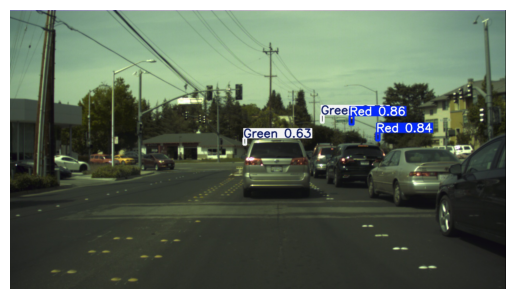

In [15]:
img = Image.open("/home/pvbm.eng23/yolo-bosch-traffic-lights/runs/detect/predict-5/17174.jpg")

plt.imshow(img)
plt.axis("off")
plt.show()